# X-ray Image Registration using CXAS Segmentation

This notebook performs automated X-ray image registration using CXAS segmentation and T4/T10 vertebrae alignment.

**Workflow:**
1. Generate rotated/shifted test image
2. Segment both images with CXAS
3. Extract T4 and T10 vertebrae landmarks
4. Compute affine transformation
5. Apply registration
6. Visualize and validate results
7. Export registered outputs

## 1. Setup and Configuration

In [ ]:
# Cell 1: Imports and Environment Setup

import os
import sys
import subprocess
import json
import numpy as np
import cv2
import matplotlib.pyplot as plt
from PIL import Image
from pathlib import Path
from scipy import ndimage
from skimage.transform import AffineTransform, warp
from skimage.metrics import structural_similarity as ssim

# Import CXAS utilities
try:
    from cxas.label_mapper import label_mapper
    from cxas.file_io import FileLoader
    CXAS_AVAILABLE = True
    print("✓ CXAS Python API available")
except ImportError:
    print("Warning: CXAS Python API not available, will use CLI only")
    CXAS_AVAILABLE = False

# Import local utilities
project_root = Path.cwd()
sys.path.insert(0, str(project_root))

try:
    from viewer.visualization import load_colors, get_label_indices_from_names, create_combined_overlay
    print("✓ Loaded viewer utilities")
except ImportError as e:
    print(f"Warning: Could not import viewer utilities: {e}")

# Set matplotlib style
plt.rcParams['figure.dpi'] = 100
plt.rcParams['figure.figsize'] = (15, 7)

print("\n✓ All imports successful")

✓ CXAS Python API available
✓ Loaded viewer utilities

✓ All imports successful


In [12]:
# Cell 2: Configuration and Constants

# Paths
PROJECT_ROOT = Path.cwd()
TEST_DATA_DIR = PROJECT_ROOT / 'test_output'
OUTPUT_DIR = PROJECT_ROOT / 'registration_output'
OUTPUT_DIR.mkdir(exist_ok=True)

# CXAS configuration
CXAS_CMD = 'cxas_segment'
DEVICE = 'cpu'  # or '0' for GPU
MODEL = 'UNet_ResNet50_default'

# Vertebrae configuration
VERTEBRAE_LABELS = {
    'T4': 'vertebrae T4',
    'T10': 'vertebrae T10'
}

# Transformation parameters for test image generation
ROTATION_ANGLE = 10  # degrees (counter-clockwise)
SHIFT_X = -100  # pixels (negative = left)
SHIFT_Y = 0  # pixels

print(f"Project root: {PROJECT_ROOT}")
print(f"Test data: {TEST_DATA_DIR}")
print(f"Output directory: {OUTPUT_DIR}")
print(f"\nCXAS device: {DEVICE}")
print(f"Transform: {ROTATION_ANGLE}° rotation, ({SHIFT_X}, {SHIFT_Y})px shift")

Project root: /Users/constantinseibold/workspace/research/matthias_cxas
Test data: /Users/constantinseibold/workspace/research/matthias_cxas/test_output
Output directory: /Users/constantinseibold/workspace/research/matthias_cxas/registration_output

CXAS device: cpu
Transform: 10° rotation, (-100, 0)px shift


Loaded: test.jpg
  Shape: (2207, 1929, 3)
  dtype: uint8
  Range: [0, 255]


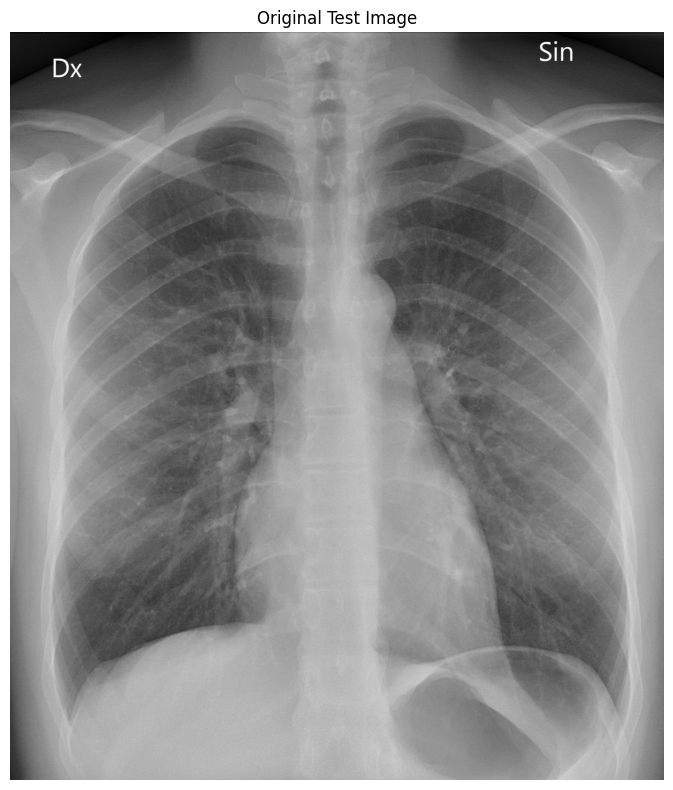

In [13]:
# Cell 3: Load Original Test Image

def load_test_image(img_path):
    """
    Load test image.
    
    Parameters
    ----------
    img_path : Path
        Path to image file
    
    Returns
    -------
    np.ndarray
        Image array [H, W, C]
    """
    img = Image.open(img_path).convert('RGB')
    img_array = np.array(img)
    
    print(f"Loaded: {img_path.name}")
    print(f"  Shape: {img_array.shape}")
    print(f"  dtype: {img_array.dtype}")
    print(f"  Range: [{img_array.min()}, {img_array.max()}]")
    
    return img_array

# Load original test image
img_path = TEST_DATA_DIR / 'images' / 'test.jpg'
img1 = load_test_image(img_path)

# Display
plt.figure(figsize=(10, 8))
plt.imshow(img1)
plt.title('Original Test Image')
plt.axis('off')
plt.tight_layout()
plt.show()

## 2. Generate Test Images

Forward transformation matrix:
[[ 9.84807753e-01  1.73648178e-01 -2.76967842e+02]
 [-1.73648178e-01  9.84807753e-01  1.84248312e+02]]


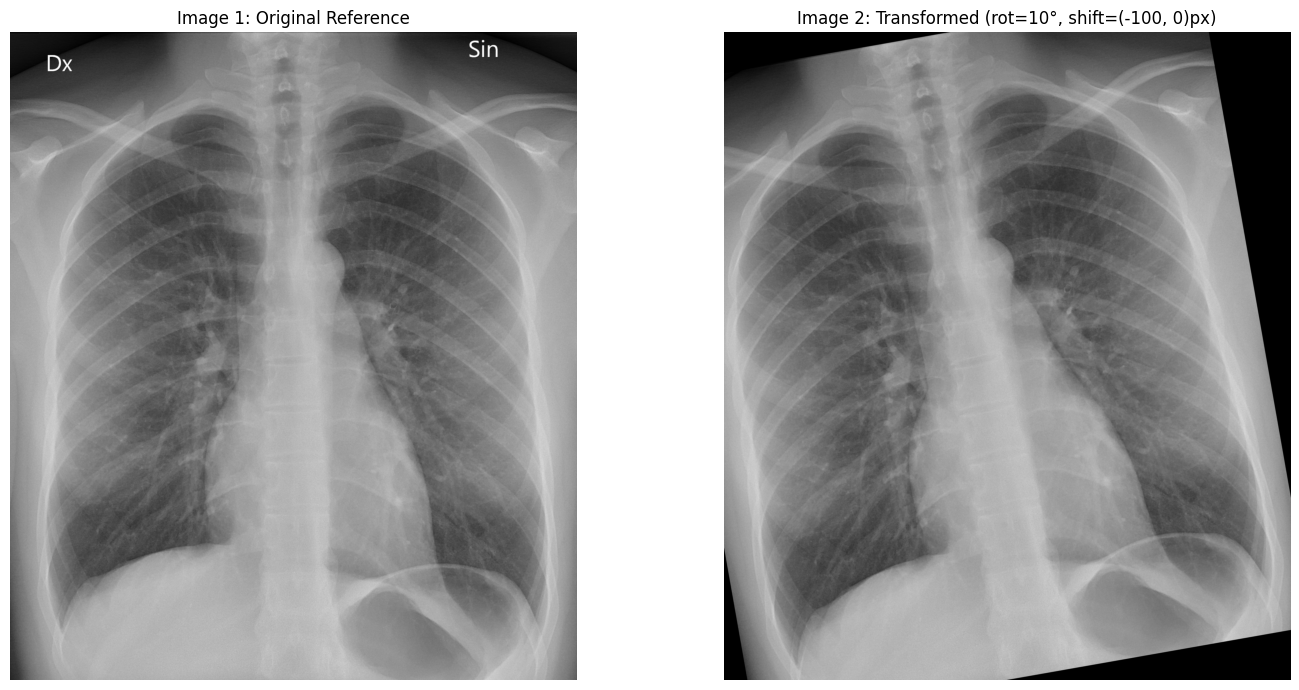

In [14]:
# Cell 4: Create Transformed Image

def generate_transformed_image(image, angle_deg, shift_x, shift_y):
    """
    Generate a rotated and translated version of the input image.
    
    Parameters
    ----------
    image : np.ndarray
        Input image [H, W, C]
    angle_deg : float
        Rotation angle in degrees (positive = counter-clockwise)
    shift_x : float
        Horizontal shift in pixels (positive = right)
    shift_y : float
        Vertical shift in pixels (positive = down)
    
    Returns
    -------
    tuple
        (transformed_image, rotation_matrix)
    """
    h, w = image.shape[:2]
    
    # Compute rotation matrix around image center
    center = (w / 2, h / 2)
    rotation_matrix = cv2.getRotationMatrix2D(center, angle_deg, scale=1.0)
    
    # Add translation to the rotation matrix
    rotation_matrix[0, 2] += shift_x
    rotation_matrix[1, 2] += shift_y
    
    # Apply transformation
    transformed = cv2.warpAffine(
        image, 
        rotation_matrix, 
        (w, h),
        flags=cv2.INTER_LINEAR,
        borderMode=cv2.BORDER_CONSTANT,
        borderValue=(0, 0, 0)
    )
    
    return transformed, rotation_matrix

# Generate second image
img2, forward_transform = generate_transformed_image(
    img1, 
    ROTATION_ANGLE, 
    SHIFT_X, 
    SHIFT_Y
)

print(f"Forward transformation matrix:")
print(forward_transform)

# Visualize both images
fig, axes = plt.subplots(1, 2, figsize=(15, 7))

axes[0].imshow(img1)
axes[0].set_title('Image 1: Original Reference')
axes[0].axis('off')

axes[1].imshow(img2)
axes[1].set_title(f'Image 2: Transformed (rot={ROTATION_ANGLE}°, shift=({SHIFT_X}, {SHIFT_Y})px)')
axes[1].axis('off')

plt.tight_layout()
plt.show()

In [15]:
# Cell 5: Save Images for Segmentation

# Create temporary directory for images
temp_dir = OUTPUT_DIR / 'temp_images'
temp_dir.mkdir(exist_ok=True)

img1_path = temp_dir / 'image1_original.jpg'
img2_path = temp_dir / 'image2_transformed.jpg'

Image.fromarray(img1).save(img1_path, quality=95)
Image.fromarray(img2).save(img2_path, quality=95)

print(f"Saved images for CXAS processing:")
print(f"  Image 1: {img1_path}")
print(f"  Image 2: {img2_path}")

Saved images for CXAS processing:
  Image 1: /Users/constantinseibold/workspace/research/matthias_cxas/registration_output/temp_images/image1_original.jpg
  Image 2: /Users/constantinseibold/workspace/research/matthias_cxas/registration_output/temp_images/image2_transformed.jpg


## 3. CXAS Segmentation

In [16]:
# Cell 6: Define Segmentation Function

def segment_image_with_cxas(image_path, output_dir, device='cpu', model='UNet_ResNet50_default'):
    """
    Run CXAS segmentation on a single image using CLI.
    
    Parameters
    ----------
    image_path : Path
        Path to input image
    output_dir : Path
        Directory for output masks
    device : str
        Device to use ('cpu' or '0' for GPU)
    model : str
        CXAS model name
    
    Returns
    -------
    Path
        Path to generated .npy mask file
    """
    output_dir.mkdir(exist_ok=True)
    
    # Build CXAS command
    cmd = [
        CXAS_CMD,
        '-i', str(image_path),
        '-o', str(output_dir),
        '-ot', 'npy',
        '-g', device,
        '-m', model
    ]
    
    print(f"\nRunning CXAS segmentation...")
    print(f"Command: {' '.join(cmd)}")
    
    try:
        result = subprocess.run(
            cmd,
            check=True,
            capture_output=True,
            text=True,
            timeout=300  # 5 minute timeout
        )
        print("✓ Segmentation successful!")
        if result.stdout:
            print(result.stdout)
    except subprocess.CalledProcessError as e:
        print(f"✗ Error running CXAS: {e}")
        if e.stderr:
            print(f"stderr: {e.stderr}")
        raise
    except FileNotFoundError:
        print(f"✗ Error: {CXAS_CMD} not found in PATH")
        print("Make sure CXAS is installed: pip install cxas")
        raise
    except subprocess.TimeoutExpired:
        print("✗ Error: Segmentation timed out after 5 minutes")
        raise
    
    # Find output mask file
    mask_filename = image_path.stem + '.npy'
    mask_path = output_dir / mask_filename
    
    if not mask_path.exists():
        raise FileNotFoundError(f"Expected mask not found: {mask_path}")
    
    return mask_path

print("✓ Segmentation function defined")

✓ Segmentation function defined


In [17]:
# Cell 7: Run Segmentation on Both Images

# Create output directory for masks
mask_dir = OUTPUT_DIR / 'temp_masks'

# Segment image 1 (original)
print("=" * 60)
print("SEGMENTING IMAGE 1 (ORIGINAL)")
print("=" * 60)
mask1_path = segment_image_with_cxas(img1_path, mask_dir, DEVICE, MODEL)
mask1 = np.load(mask1_path)
print(f"\nMask 1 loaded:")
print(f"  Path: {mask1_path}")
print(f"  Shape: {mask1.shape}")
print(f"  dtype: {mask1.dtype}")
print(f"  Channels: {mask1.shape[0]}")

# Segment image 2 (transformed)
print("\n" + "=" * 60)
print("SEGMENTING IMAGE 2 (TRANSFORMED)")
print("=" * 60)
mask2_path = segment_image_with_cxas(img2_path, mask_dir, DEVICE, MODEL)
mask2 = np.load(mask2_path)
print(f"\nMask 2 loaded:")
print(f"  Path: {mask2_path}")
print(f"  Shape: {mask2.shape}")
print(f"  dtype: {mask2.dtype}")
print(f"  Channels: {mask2.shape[0]}")

print("\n" + "=" * 60)
print("✓ Both images segmented successfully")
print("=" * 60)

SEGMENTING IMAGE 1 (ORIGINAL)

Running CXAS segmentation...
Command: cxas_segment -i /Users/constantinseibold/workspace/research/matthias_cxas/registration_output/temp_images/image1_original.jpg -o /Users/constantinseibold/workspace/research/matthias_cxas/registration_output/temp_masks -ot npy -g cpu -m UNet_ResNet50_default
✓ Segmentation successful!

Mask 1 loaded:
  Path: /Users/constantinseibold/workspace/research/matthias_cxas/registration_output/temp_masks/image1_original.npy
  Shape: (159, 2207, 1929)
  dtype: bool
  Channels: 159

SEGMENTING IMAGE 2 (TRANSFORMED)

Running CXAS segmentation...
Command: cxas_segment -i /Users/constantinseibold/workspace/research/matthias_cxas/registration_output/temp_images/image2_transformed.jpg -o /Users/constantinseibold/workspace/research/matthias_cxas/registration_output/temp_masks -ot npy -g cpu -m UNet_ResNet50_default
✓ Segmentation successful!

Mask 2 loaded:
  Path: /Users/constantinseibold/workspace/research/matthias_cxas/registration_

## 4. Extract Vertebrae Landmarks

In [18]:
# Cell 8: Get Vertebrae Indices

def get_vertebrae_indices():
    """
    Get the channel indices for T4 and T10 vertebrae.
    
    Returns
    -------
    dict
        Dictionary mapping vertebrae names to indices
    """
    try:
        from cxas.label_mapper import label_mapper
        
        indices = {}
        for name, label in VERTEBRAE_LABELS.items():
            if label in label_mapper:
                idx = label_mapper[label]
                # Handle case where label_mapper returns list
                if isinstance(idx, list):
                    idx = idx[0] if len(idx) > 0 else None
                indices[name] = idx
            else:
                print(f"Warning: '{label}' not found in label_mapper")
                indices[name] = None
        
        return indices
    except ImportError:
        # Fallback to hardcoded indices based on exploration
        print("CXAS label_mapper not available, using hardcoded vertebrae indices")
        return {'T4': 14, 'T10': 20}

vertebrae_indices = get_vertebrae_indices()
print(f"\nVertebrae indices:")
for name, idx in vertebrae_indices.items():
    label = VERTEBRAE_LABELS[name]
    print(f"  {name} ('{label}'): channel {idx}")


Vertebrae indices:
  T4 ('vertebrae T4'): channel 14
  T10 ('vertebrae T10'): channel 20


In [19]:
# Cell 9: Compute Centroids

def compute_centroid(mask_2d):
    """
    Compute centroid of a binary mask.
    
    Parameters
    ----------
    mask_2d : np.ndarray
        Binary mask [H, W]
    
    Returns
    -------
    tuple or None
        (x, y) centroid coordinates, or None if mask is empty
    """
    if not mask_2d.any():
        return None
    
    # Use cv2.moments for accurate centroid calculation
    M = cv2.moments(mask_2d.astype(np.uint8))
    if M["m00"] == 0:
        return None
    cx = M["m10"] / M["m00"]
    cy = M["m01"] / M["m00"]
    
    return (cx, cy)

def extract_vertebrae_centroids(mask, vertebrae_indices, min_area_pixels=100):
    """
    Extract centroids for T4 and T10 vertebrae.
    
    Parameters
    ----------
    mask : np.ndarray
        Segmentation mask [159, H, W]
    vertebrae_indices : dict
        Dictionary mapping vertebrae names to channel indices
    min_area_pixels : int
        Minimum area for valid detection
    
    Returns
    -------
    dict
        Dictionary mapping vertebrae names to (x, y) centroids
    """
    centroids = {}
    
    for name, idx in vertebrae_indices.items():
        if idx is None or idx >= mask.shape[0]:
            print(f"  ✗ {name}: Invalid index {idx}")
            centroids[name] = None
            continue
        
        vertebra_mask = mask[idx, :, :]
        area = vertebra_mask.sum()
        
        if area < min_area_pixels:
            print(f"  ✗ {name}: Detection failed (area {area} < {min_area_pixels} pixels)")
            centroids[name] = None
            continue
        
        centroid = compute_centroid(vertebra_mask)
        
        if centroid is None:
            print(f"  ✗ {name}: Centroid computation failed")
        else:
            print(f"  ✓ {name}: centroid ({centroid[0]:.1f}, {centroid[1]:.1f}), area {area} px")
        
        centroids[name] = centroid
    
    return centroids

# Extract centroids from both masks
print("\nImage 1 vertebrae centroids:")
centroids1 = extract_vertebrae_centroids(mask1, vertebrae_indices)

print("\nImage 2 vertebrae centroids:")
centroids2 = extract_vertebrae_centroids(mask2, vertebrae_indices)

# Validate that we have both landmarks
valid_landmarks = all(centroids1[name] is not None and centroids2[name] is not None 
                      for name in ['T4', 'T10'])

if valid_landmarks:
    print("\n✓ All vertebrae detected successfully")
else:
    print("\n✗ Warning: Some vertebrae not detected. Registration may fail.")


Image 1 vertebrae centroids:
  ✓ T4: centroid (947.5, 555.4), area 62344 px
  ✓ T10: centroid (976.4, 1575.9), area 69621 px

Image 2 vertebrae centroids:
  ✓ T4: centroid (752.6, 557.5), area 57788 px
  ✓ T10: centroid (953.7, 1584.0), area 81720 px

✓ All vertebrae detected successfully


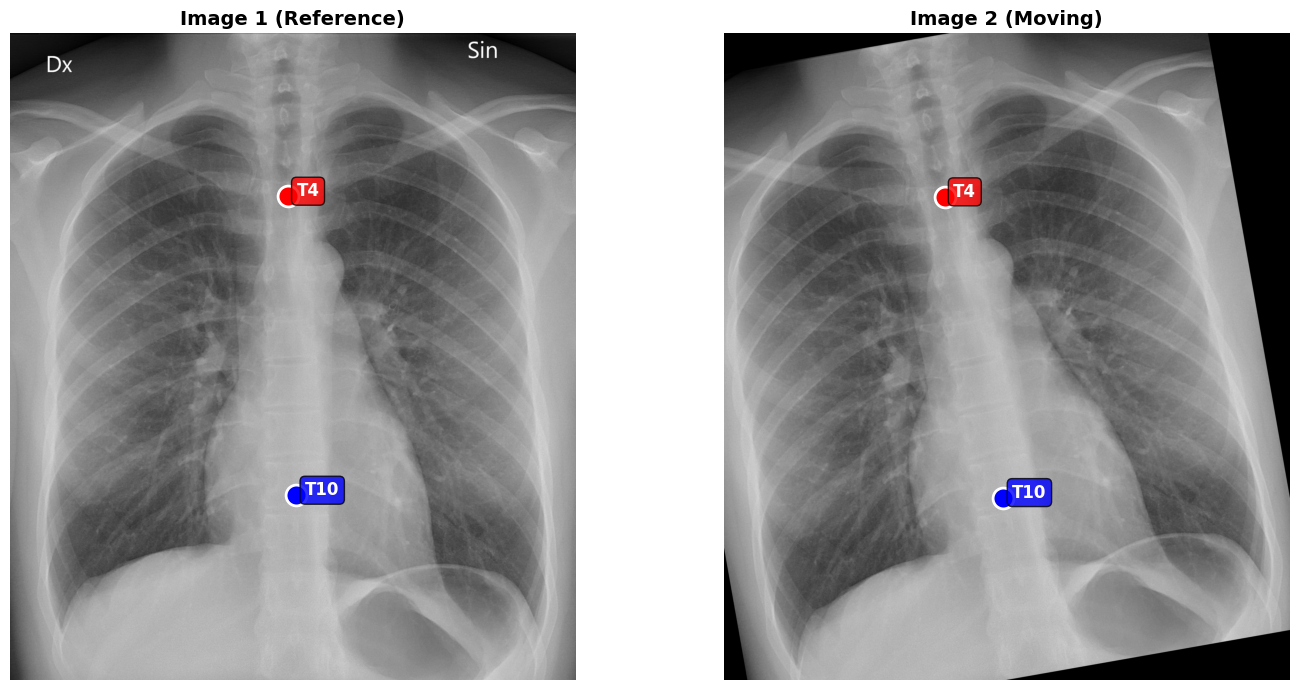

In [20]:
# Cell 10: Visualize Landmarks

def visualize_landmarks(img1, img2, centroids1, centroids2):
    """
    Visualize the detected landmarks on both images.
    
    Parameters
    ----------
    img1, img2 : np.ndarray
        Images to display
    centroids1, centroids2 : dict
        Centroid dictionaries
    """
    fig, axes = plt.subplots(1, 2, figsize=(15, 7))
    
    colors = {'T4': 'red', 'T10': 'blue'}
    
    for ax, img, centroids, title in zip(
        axes, 
        [img1, img2], 
        [centroids1, centroids2],
        ['Image 1 (Reference)', 'Image 2 (Moving)']
    ):
        ax.imshow(img)
        ax.set_title(title, fontsize=14, fontweight='bold')
        ax.axis('off')
        
        # Plot centroids
        for name, centroid in centroids.items():
            if centroid is not None:
                x, y = centroid
                color = colors.get(name, 'yellow')
                
                # Plot marker
                ax.plot(x, y, 'o', color=color, markersize=15, 
                       markeredgecolor='white', markeredgewidth=2)
                
                # Add label
                ax.text(x + 30, y, name, color='white', fontsize=12, 
                       fontweight='bold', 
                       bbox=dict(boxstyle='round', facecolor=color, alpha=0.8))
    
    plt.tight_layout()
    plt.show()

# Visualize landmarks
visualize_landmarks(img1, img2, centroids1, centroids2)

## 5. Compute Affine Transformation

In [21]:
# Cell 11: Calculate Transformation Matrix

def compute_affine_from_landmarks(src_points, dst_points):
    """
    Compute affine transformation from source to destination landmark points.
    
    Uses similarity transform (rotation + translation + uniform scale) which
    is exactly solvable with 2 point pairs.
    
    Parameters
    ----------
    src_points : np.ndarray
        Source points, shape (N, 2) where N >= 2
    dst_points : np.ndarray
        Destination points, shape (N, 2)
    
    Returns
    -------
    np.ndarray
        Affine transformation matrix (2, 3) for cv2.warpAffine
    """
    # Use estimateAffinePartial2D for similarity transform (4 DOF)
    # This works with exactly 2 points, unlike estimateAffine2D which needs more points for RANSAC
    M, inliers = cv2.estimateAffinePartial2D(src_points, dst_points)
    
    if M is None:
        # Fallback: compute manually from 2 points
        print("Warning: estimateAffinePartial2D failed, computing manually...")
        if len(src_points) == 2:
            M = compute_similarity_transform_manual(src_points, dst_points)
        else:
            raise ValueError("Could not compute affine transformation")
    
    return M

def compute_similarity_transform_manual(src_pts, dst_pts):
    """
    Manually compute similarity transform from 2 point pairs.
    
    Similarity transform: x' = s*R*x + t
    where s is scale, R is rotation, t is translation
    """
    # Source and destination vectors
    src_vec = src_pts[1] - src_pts[0]  # Vector from T4 to T10
    dst_vec = dst_pts[1] - dst_pts[0]
    
    # Compute scale
    src_len = np.linalg.norm(src_vec)
    dst_len = np.linalg.norm(dst_vec)
    scale = dst_len / src_len if src_len > 0 else 1.0
    
    # Compute rotation angle
    src_angle = np.arctan2(src_vec[1], src_vec[0])
    dst_angle = np.arctan2(dst_vec[1], dst_vec[0])
    angle = dst_angle - src_angle
    
    # Build transformation matrix
    cos_a = np.cos(angle)
    sin_a = np.sin(angle)
    
    # Apply scale and rotation
    a = scale * cos_a
    b = scale * (-sin_a)
    c = scale * sin_a
    d = scale * cos_a
    
    # Compute translation to align first point
    # dst_pts[0] = scale * R * src_pts[0] + t
    # t = dst_pts[0] - scale * R * src_pts[0]
    rotated_src = np.array([
        a * src_pts[0, 0] + b * src_pts[0, 1],
        c * src_pts[0, 0] + d * src_pts[0, 1]
    ])
    tx = dst_pts[0, 0] - rotated_src[0]
    ty = dst_pts[0, 1] - rotated_src[1]
    
    M = np.array([
        [a, b, tx],
        [c, d, ty]
    ], dtype=np.float32)
    
    return M

# Prepare point arrays for affine estimation
# We want to transform img2 to align with img1, so:
# - src_points: centroids from img2 (moving image)
# - dst_points: centroids from img1 (reference image)

src_points = []
dst_points = []

for name in ['T4', 'T10']:
    if centroids2[name] is not None and centroids1[name] is not None:
        src_points.append(centroids2[name])
        dst_points.append(centroids1[name])
    else:
        raise ValueError(f"{name} centroid missing, cannot compute registration")

if len(src_points) < 2:
    raise ValueError("Need at least 2 landmark pairs for affine registration")

src_points = np.array(src_points, dtype=np.float32)
dst_points = np.array(dst_points, dtype=np.float32)

print(f"Source points (img2 → img1):")
print(src_points)
print(f"\nDestination points (img1):")
print(dst_points)

# Compute affine transformation
affine_matrix = compute_affine_from_landmarks(src_points, dst_points)

print(f"\nComputed affine transformation matrix (2×3):")
print(affine_matrix)
print("\n✓ Affine transformation computed successfully")

Source points (img2 → img1):
[[ 752.61884  557.5099 ]
 [ 953.7245  1583.9679 ]]

Destination points (img1):
[[ 947.4706   555.41266]
 [ 976.4282  1575.9043 ]]

Computed affine transformation matrix (2×3):
[[ 9.62758730e-01 -1.60414337e-01  3.12312805e+02]
 [ 1.60414337e-01  9.62758730e-01 -1.02065704e+02]]

✓ Affine transformation computed successfully


In [22]:
# Cell 12: Decompose and Analyze Transform

def decompose_affine_matrix(M):
    """
    Decompose affine matrix into rotation, scale, and translation.
    
    Parameters
    ----------
    M : np.ndarray
        Affine matrix (2, 3)
    
    Returns
    -------
    dict
        Dictionary with rotation_deg, scale_x, scale_y, tx, ty
    """
    # Extract components
    a = M[0, 0]
    b = M[0, 1]
    c = M[1, 0]
    d = M[1, 1]
    
    # Compute scale
    scale_x = np.sqrt(a**2 + c**2)
    scale_y = np.sqrt(b**2 + d**2)
    
    # Compute rotation (assuming uniform scaling)
    rotation_rad = np.arctan2(c, a)
    rotation_deg = np.degrees(rotation_rad)
    
    # Translation
    tx = M[0, 2]
    ty = M[1, 2]
    
    return {
        'rotation_deg': rotation_deg,
        'scale_x': scale_x,
        'scale_y': scale_y,
        'tx': tx,
        'ty': ty
    }

params = decompose_affine_matrix(affine_matrix)

print("Computed transformation parameters:")
print(f"  Rotation: {params['rotation_deg']:.2f}°")
print(f"  Scale X: {params['scale_x']:.4f}")
print(f"  Scale Y: {params['scale_y']:.4f}")
print(f"  Translation X: {params['tx']:.2f} px")
print(f"  Translation Y: {params['ty']:.2f} px")

print("\nExpected transformation (inverse of forward):")
print(f"  Rotation: ~{-ROTATION_ANGLE}°")
print(f"  Scale: ~1.0")
print(f"  Translation X: ~{-SHIFT_X} px")
print(f"  Translation Y: ~{-SHIFT_Y} px")

# Compute errors
rotation_error = abs(params['rotation_deg'] - (-ROTATION_ANGLE))
scale_error = max(abs(params['scale_x'] - 1.0), abs(params['scale_y'] - 1.0))
translation_error = np.sqrt((params['tx'] - (-SHIFT_X))**2 + (params['ty'] - (-SHIFT_Y))**2)

print("\nEstimation errors:")
print(f"  Rotation error: {rotation_error:.2f}°")
print(f"  Scale error: {scale_error:.4f}")
print(f"  Translation error: {translation_error:.2f} px")

Computed transformation parameters:
  Rotation: 9.46°
  Scale X: 0.9760
  Scale Y: 0.9760
  Translation X: 312.31 px
  Translation Y: -102.07 px

Expected transformation (inverse of forward):
  Rotation: ~-10°
  Scale: ~1.0
  Translation X: ~100 px
  Translation Y: ~0 px

Estimation errors:
  Rotation error: 19.46°
  Scale error: 0.0240
  Translation error: 235.57 px


## 6. Apply Registration

✓ Image registered
  Original shape: (2207, 1929, 3)
  Registered shape: (2207, 1929, 3)


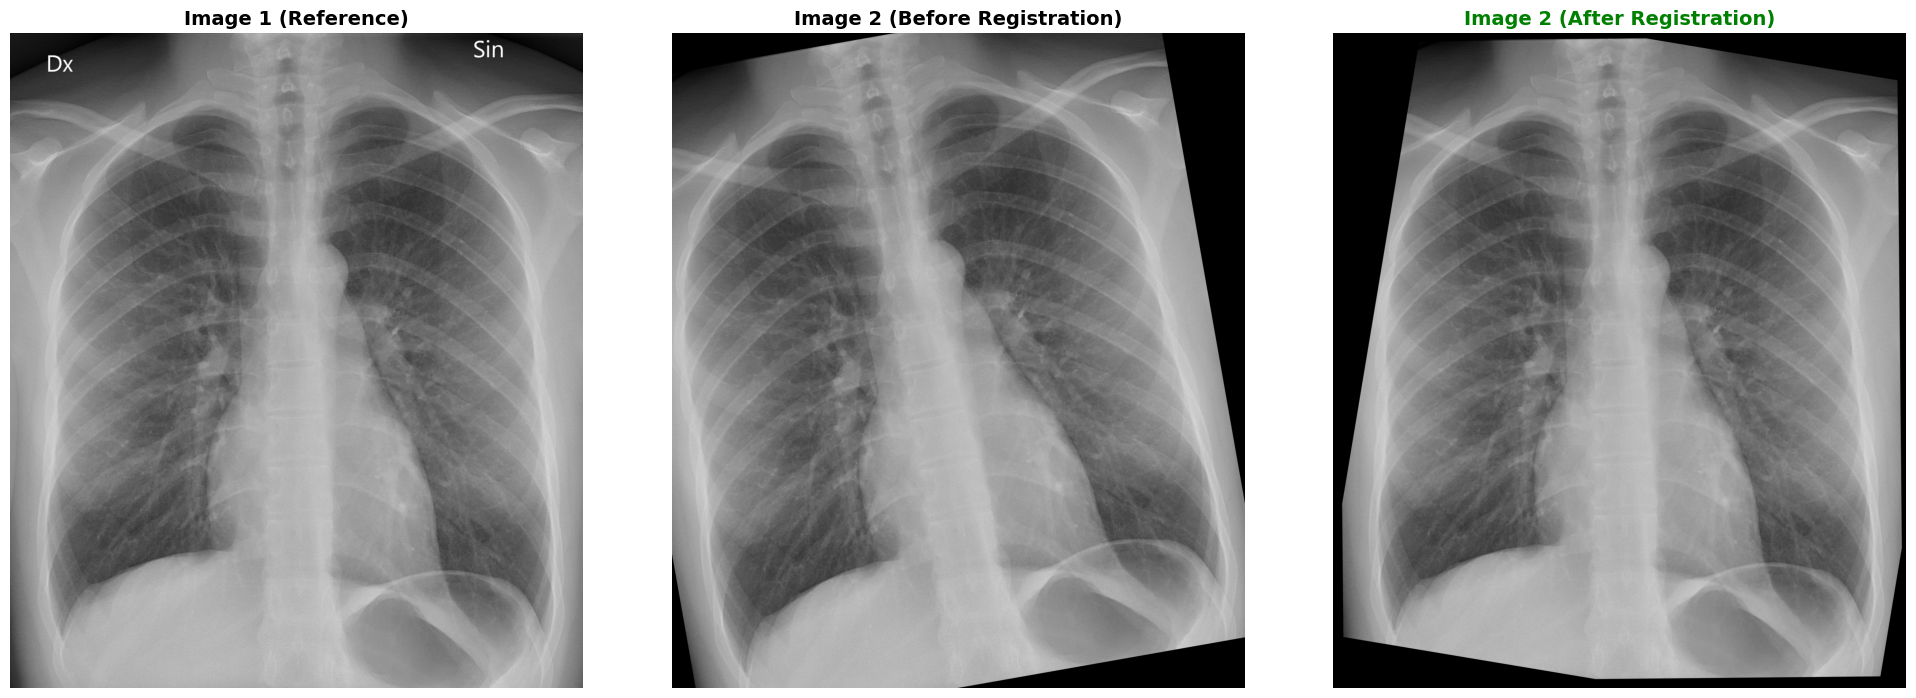

In [23]:
# Cell 13: Transform Image

def apply_affine_to_image(image, affine_matrix):
    """
    Apply affine transformation to image.
    
    Parameters
    ----------
    image : np.ndarray
        Input image [H, W, C] or [H, W]
    affine_matrix : np.ndarray
        Affine transformation matrix (2, 3)
    
    Returns
    -------
    np.ndarray
        Transformed image with same shape as input
    """
    h, w = image.shape[:2]
    
    transformed = cv2.warpAffine(
        image,
        affine_matrix,
        (w, h),
        flags=cv2.INTER_LINEAR,
        borderMode=cv2.BORDER_CONSTANT,
        borderValue=(0, 0, 0)
    )
    
    return transformed

# Apply transformation to image 2
img2_registered = apply_affine_to_image(img2, affine_matrix)

print(f"✓ Image registered")
print(f"  Original shape: {img2.shape}")
print(f"  Registered shape: {img2_registered.shape}")

# Visualize results
fig, axes = plt.subplots(1, 3, figsize=(20, 7))

axes[0].imshow(img1)
axes[0].set_title('Image 1 (Reference)', fontsize=14, fontweight='bold')
axes[0].axis('off')

axes[1].imshow(img2)
axes[1].set_title('Image 2 (Before Registration)', fontsize=14, fontweight='bold')
axes[1].axis('off')

axes[2].imshow(img2_registered)
axes[2].set_title('Image 2 (After Registration)', fontsize=14, fontweight='bold', color='green')
axes[2].axis('off')

plt.tight_layout()
plt.show()

In [24]:
# Cell 14: Transform Mask

def apply_affine_to_mask(mask, affine_matrix):
    """
    Apply affine transformation to multi-channel segmentation mask.
    
    Parameters
    ----------
    mask : np.ndarray
        Segmentation mask [N_channels, H, W]
    affine_matrix : np.ndarray
        Affine transformation matrix (2, 3)
    
    Returns
    -------
    np.ndarray
        Transformed mask with same shape as input
    """
    n_channels, h, w = mask.shape
    transformed_mask = np.zeros_like(mask)
    
    # Transform each channel independently
    for i in range(n_channels):
        # Convert bool to uint8 for interpolation
        channel = mask[i].astype(np.uint8) * 255
        
        # Apply transformation with nearest neighbor interpolation
        # (important for binary masks)
        transformed_channel = cv2.warpAffine(
            channel,
            affine_matrix,
            (w, h),
            flags=cv2.INTER_NEAREST,
            borderMode=cv2.BORDER_CONSTANT,
            borderValue=0
        )
        
        # Convert back to bool
        transformed_mask[i] = transformed_channel > 127
    
    return transformed_mask

# Apply transformation to mask 2
print("Transforming segmentation mask (159 channels)...")
mask2_registered = apply_affine_to_mask(mask2, affine_matrix)

print(f"✓ Mask registered")
print(f"  Original shape: {mask2.shape}")
print(f"  Registered shape: {mask2_registered.shape}")

# Verify vertebrae alignment
print("\nVerifying vertebrae centroids after registration:")
centroids2_registered = extract_vertebrae_centroids(mask2_registered, vertebrae_indices)

print("\nAlignment comparison:")
print(f"{'Vertebra':<10} {'Reference (img1)':<25} {'Registered (img2)':<25} {'Distance (px)'}")
print("-" * 85)
for name in ['T4', 'T10']:
    if centroids1[name] and centroids2_registered[name]:
        c1 = centroids1[name]
        c2 = centroids2_registered[name]
        distance = np.sqrt((c1[0] - c2[0])**2 + (c1[1] - c2[1])**2)
        print(f"{name:<10} ({c1[0]:6.1f}, {c1[1]:6.1f})<13 ({c2[0]:6.1f}, {c2[1]:6.1f})<13 {distance:6.2f}")
    else:
        print(f"{name:<10} ✗ Missing centroid")

print("\n✓ Registration complete")

Transforming segmentation mask (159 channels)...
✓ Mask registered
  Original shape: (159, 2207, 1929)
  Registered shape: (159, 2207, 1929)

Verifying vertebrae centroids after registration:
  ✓ T4: centroid (947.5, 555.4), area 55043 px
  ✓ T10: centroid (976.4, 1575.9), area 77827 px

Alignment comparison:
Vertebra   Reference (img1)          Registered (img2)         Distance (px)
-------------------------------------------------------------------------------------
T4         ( 947.5,  555.4)<13 ( 947.5,  555.4)<13   0.05
T10        ( 976.4, 1575.9)<13 ( 976.4, 1575.9)<13   0.01

✓ Registration complete


## 7. Create Visualizations

Creating visualizations...


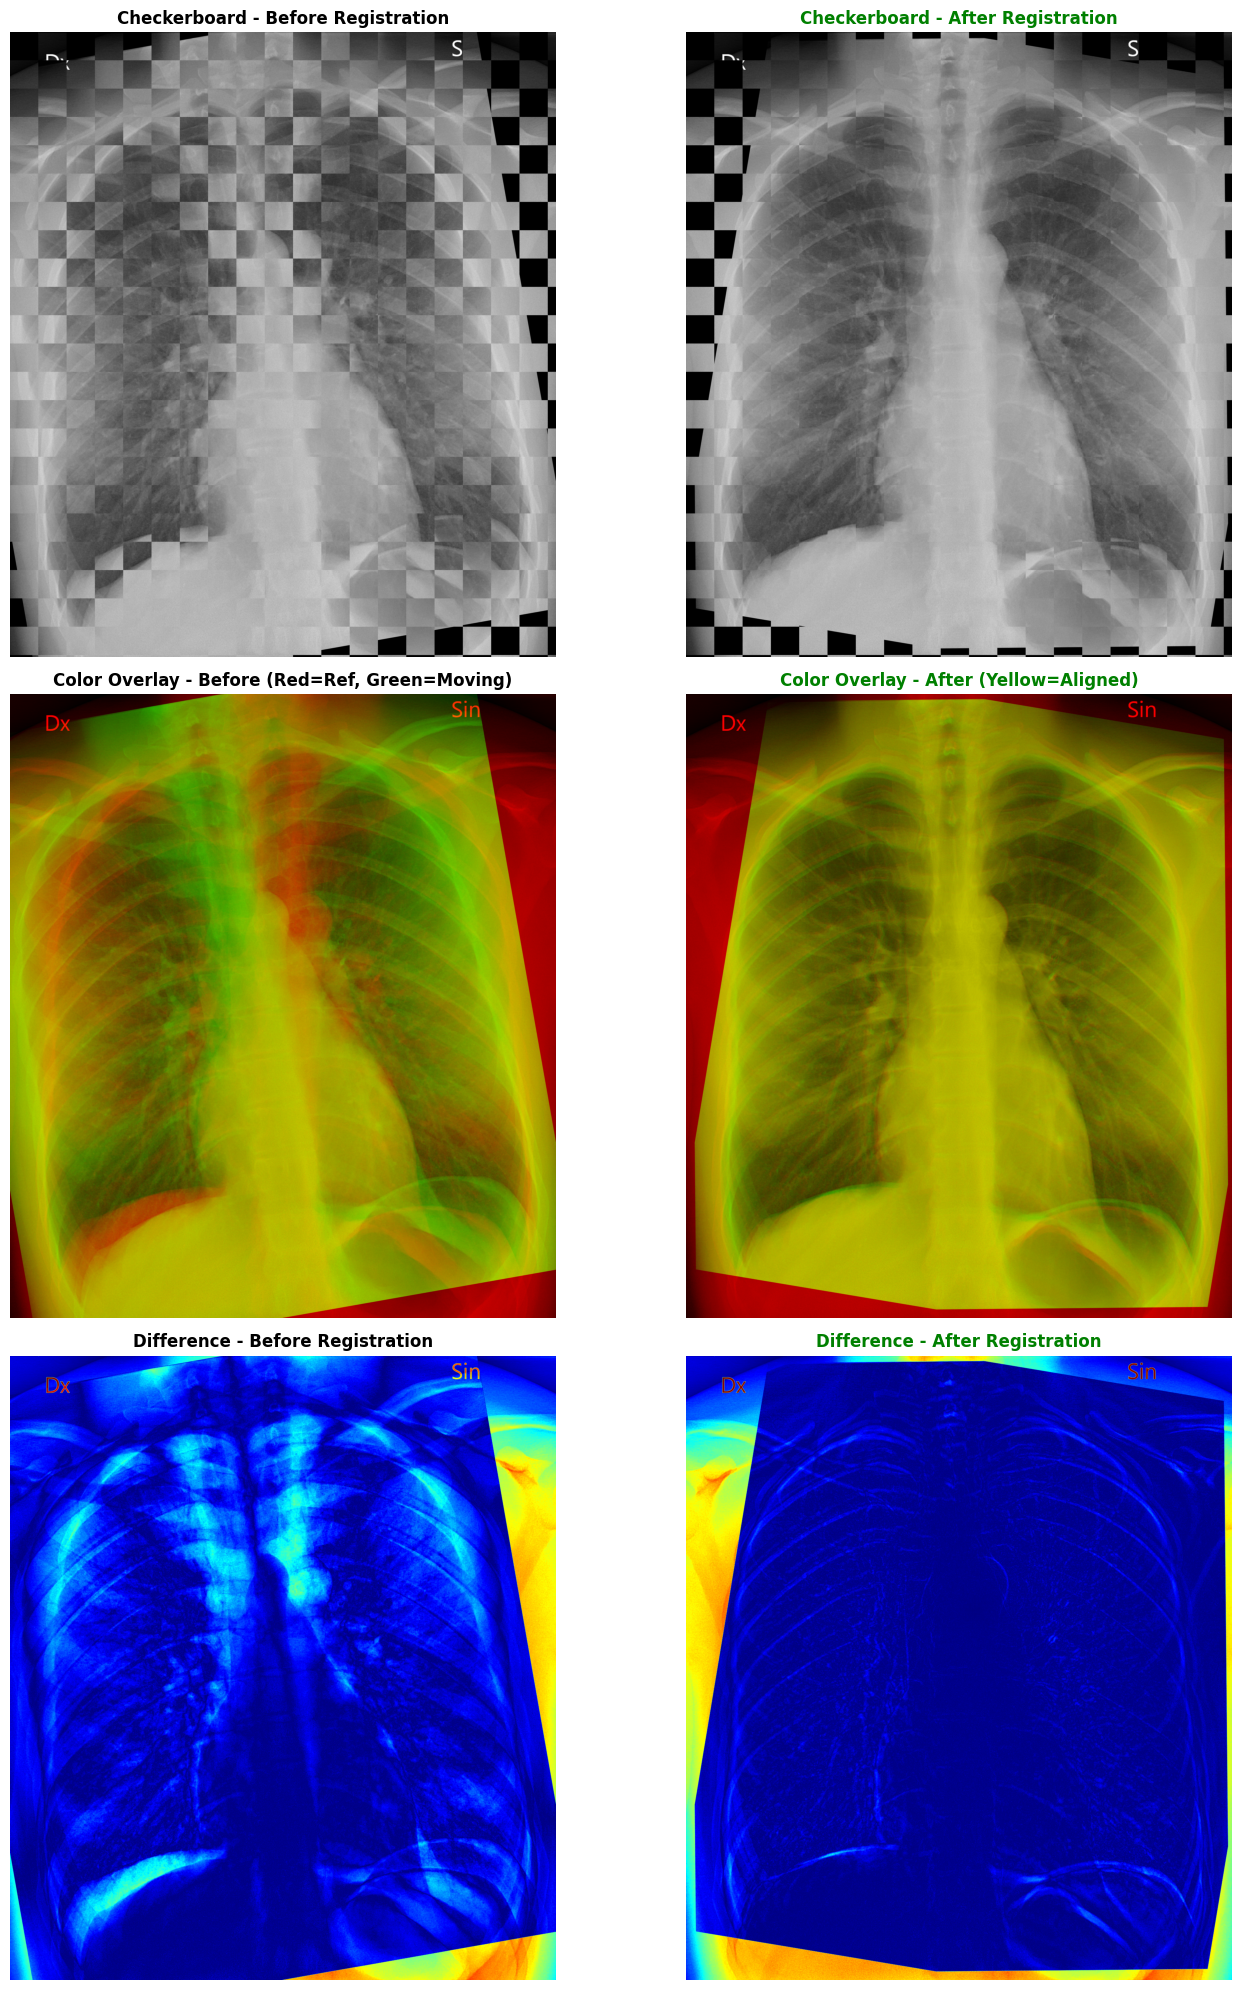

✓ Saved: /Users/constantinseibold/workspace/research/matthias_cxas/registration_output/registration_comparison.png


In [25]:
# Cell 15: Generate Comparison Overlays

def create_checkerboard(img1, img2, square_size=100):
    """
    Create checkerboard visualization of two images.
    """
    h, w = img1.shape[:2]
    checkerboard = img1.copy()
    
    for i in range(0, h, square_size):
        for j in range(0, w, square_size):
            if ((i // square_size) + (j // square_size)) % 2 == 0:
                i_end = min(i + square_size, h)
                j_end = min(j + square_size, w)
                checkerboard[i:i_end, j:j_end] = img2[i:i_end, j:j_end]
    
    return checkerboard

def create_color_overlay(img1, img2):
    """
    Create color overlay where img1 is red and img2 is green.
    Perfect alignment = yellow.
    """
    # Convert to grayscale if needed
    if len(img1.shape) == 3:
        gray1 = cv2.cvtColor(img1, cv2.COLOR_RGB2GRAY)
        gray2 = cv2.cvtColor(img2, cv2.COLOR_RGB2GRAY)
    else:
        gray1 = img1
        gray2 = img2
    
    # Create RGB overlay
    overlay = np.zeros((*gray1.shape, 3), dtype=np.uint8)
    overlay[:, :, 0] = gray1  # Red channel
    overlay[:, :, 1] = gray2  # Green channel
    overlay[:, :, 2] = 0       # Blue channel
    
    return overlay

def create_difference_image(img1, img2):
    """
    Create difference image showing misalignment.
    """
    if len(img1.shape) == 3:
        gray1 = cv2.cvtColor(img1, cv2.COLOR_RGB2GRAY)
        gray2 = cv2.cvtColor(img2, cv2.COLOR_RGB2GRAY)
    else:
        gray1 = img1
        gray2 = img2
    
    diff = np.abs(gray1.astype(float) - gray2.astype(float))
    diff = (diff / diff.max() * 255).astype(np.uint8)
    
    # Apply colormap for better visualization
    diff_color = cv2.applyColorMap(diff, cv2.COLORMAP_JET)
    diff_color = cv2.cvtColor(diff_color, cv2.COLOR_BGR2RGB)
    
    return diff_color

# Create all visualizations
print("Creating visualizations...")
checkerboard_before = create_checkerboard(img1, img2)
checkerboard_after = create_checkerboard(img1, img2_registered)

color_overlay_before = create_color_overlay(img1, img2)
color_overlay_after = create_color_overlay(img1, img2_registered)

diff_before = create_difference_image(img1, img2)
diff_after = create_difference_image(img1, img2_registered)

# Display comprehensive comparison
fig, axes = plt.subplots(3, 2, figsize=(15, 20))

axes[0, 0].imshow(checkerboard_before)
axes[0, 0].set_title('Checkerboard - Before Registration', fontsize=12, fontweight='bold')
axes[0, 0].axis('off')

axes[0, 1].imshow(checkerboard_after)
axes[0, 1].set_title('Checkerboard - After Registration', fontsize=12, fontweight='bold', color='green')
axes[0, 1].axis('off')

axes[1, 0].imshow(color_overlay_before)
axes[1, 0].set_title('Color Overlay - Before (Red=Ref, Green=Moving)', fontsize=12, fontweight='bold')
axes[1, 0].axis('off')

axes[1, 1].imshow(color_overlay_after)
axes[1, 1].set_title('Color Overlay - After (Yellow=Aligned)', fontsize=12, fontweight='bold', color='green')
axes[1, 1].axis('off')

axes[2, 0].imshow(diff_before)
axes[2, 0].set_title('Difference - Before Registration', fontsize=12, fontweight='bold')
axes[2, 0].axis('off')

axes[2, 1].imshow(diff_after)
axes[2, 1].set_title('Difference - After Registration', fontsize=12, fontweight='bold', color='green')
axes[2, 1].axis('off')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'registration_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"✓ Saved: {OUTPUT_DIR / 'registration_comparison.png'}")

Creating vertebrae segmentation overlays...


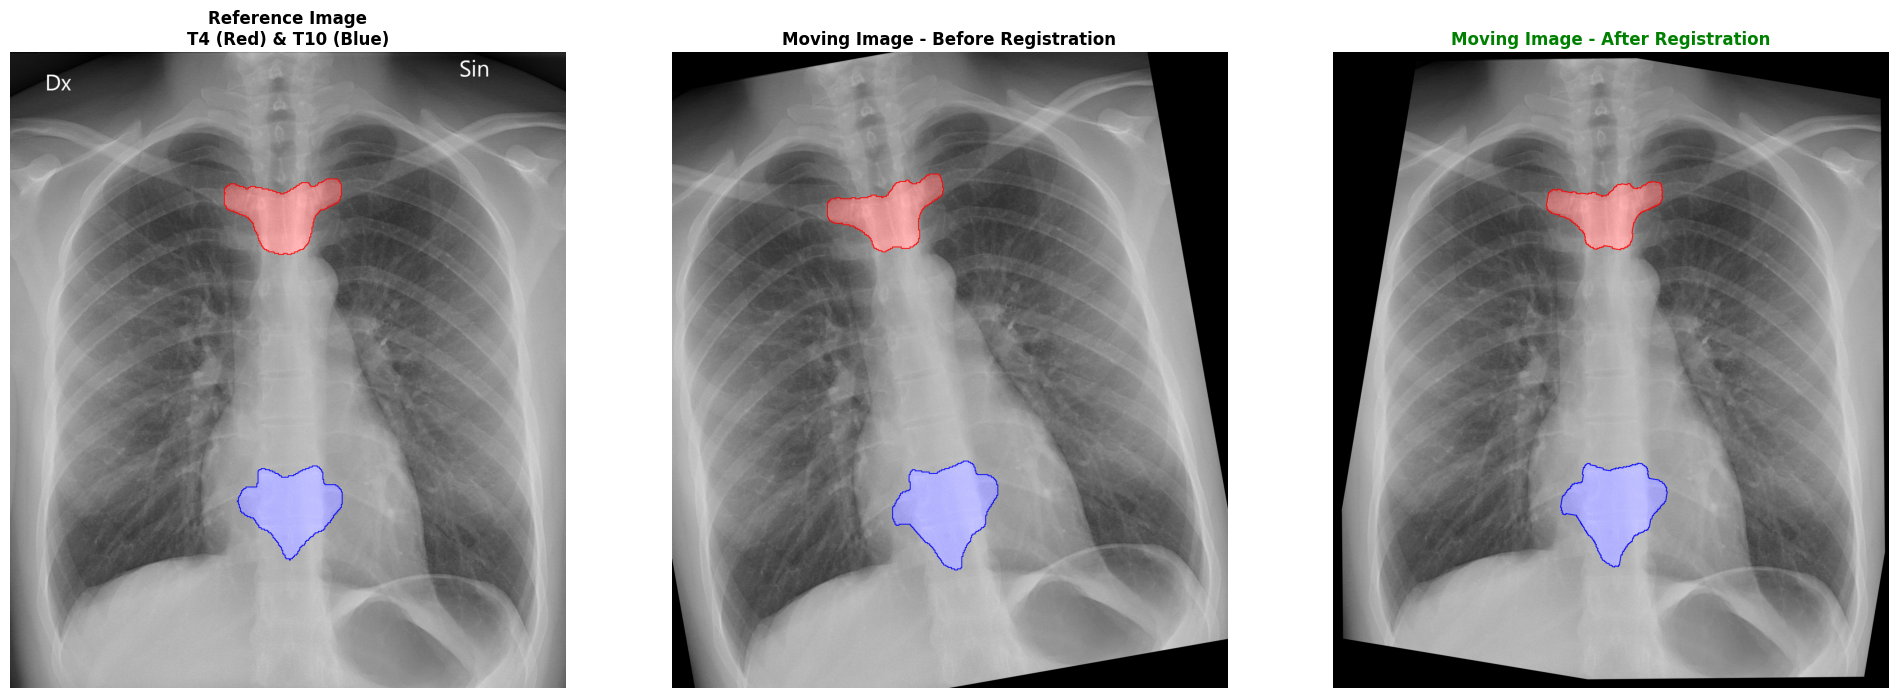

✓ Saved: /Users/constantinseibold/workspace/research/matthias_cxas/registration_output/segmentation_overlay.png


In [26]:
# Cell 16: Vertebrae Segmentation Overlay

def create_vertebrae_overlay(image, mask, vertebrae_indices, fill_opacity=0.3, contour_thickness=2):
    """
    Create overlay visualization for vertebrae segmentation.
    
    Parameters
    ----------
    image : np.ndarray
        Base image [H, W, C]
    mask : np.ndarray
        Segmentation mask [159, H, W]
    vertebrae_indices : dict
        Dictionary of vertebrae indices
    fill_opacity : float
        Opacity for filled regions
    contour_thickness : int
        Thickness of contour lines
    
    Returns
    -------
    np.ndarray
        Overlay image
    """
    overlay = image.copy()
    colors = {'T4': (255, 0, 0), 'T10': (0, 0, 255)}  # T4=red, T10=blue
    
    for name, idx in vertebrae_indices.items():
        if idx is None or idx >= mask.shape[0]:
            continue
        
        vertebra_mask = mask[idx, :, :]
        if not vertebra_mask.any():
            continue
        
        color = colors.get(name, (255, 255, 0))
        
        # Create colored overlay
        color_mask = np.zeros_like(overlay)
        color_mask[vertebra_mask] = color
        
        # Blend with image
        overlay = cv2.addWeighted(overlay, 1.0, color_mask, fill_opacity, 0)
        
        # Add contours
        mask_uint8 = (vertebra_mask * 255).astype(np.uint8)
        contours, _ = cv2.findContours(mask_uint8, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        cv2.drawContours(overlay, contours, -1, color, contour_thickness)
    
    return overlay

# Create overlays
print("Creating vertebrae segmentation overlays...")
overlay1 = create_vertebrae_overlay(img1, mask1, vertebrae_indices)
overlay2_before = create_vertebrae_overlay(img2, mask2, vertebrae_indices)
overlay2_after = create_vertebrae_overlay(img2_registered, mask2_registered, vertebrae_indices)

fig, axes = plt.subplots(1, 3, figsize=(20, 7))

axes[0].imshow(overlay1)
axes[0].set_title('Reference Image\nT4 (Red) & T10 (Blue)', fontsize=12, fontweight='bold')
axes[0].axis('off')

axes[1].imshow(overlay2_before)
axes[1].set_title('Moving Image - Before Registration', fontsize=12, fontweight='bold')
axes[1].axis('off')

axes[2].imshow(overlay2_after)
axes[2].set_title('Moving Image - After Registration', fontsize=12, fontweight='bold', color='green')
axes[2].axis('off')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'segmentation_overlay.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"✓ Saved: {OUTPUT_DIR / 'segmentation_overlay.png'}")

## 8. Save Results and Validation

In [27]:
# Cell 17: Export Registered Outputs

# Create final output directory structure
final_output = OUTPUT_DIR / 'final_results'
final_output.mkdir(exist_ok=True)

# Save registered image
registered_img_path = final_output / 'registered_image.jpg'
Image.fromarray(img2_registered).save(registered_img_path, quality=95)

# Save registered mask
registered_mask_path = final_output / 'registered_mask.npy'
np.save(registered_mask_path, mask2_registered)

# Save transformation matrix
affine_matrix_path = final_output / 'affine_matrix.txt'
np.savetxt(
    affine_matrix_path, 
    affine_matrix,
    header='Affine transformation matrix (2x3)\nFormat: [[a, b, tx], [c, d, ty]]'
)

# Save metadata
metadata = {
    'input_images': {
        'reference': str(img1_path),
        'moving': str(img2_path)
    },
    'transformation_parameters': {
        'rotation_deg': float(params['rotation_deg']),
        'scale_x': float(params['scale_x']),
        'scale_y': float(params['scale_y']),
        'translation_x': float(params['tx']),
        'translation_y': float(params['ty'])
    },
    'vertebrae_centroids': {
        'reference': {k: list(v) if v else None for k, v in centroids1.items()},
        'moving_before': {k: list(v) if v else None for k, v in centroids2.items()},
        'moving_after': {k: list(v) if v else None for k, v in centroids2_registered.items()}
    },
    'alignment_error_pixels': {
        name: float(np.sqrt((centroids1[name][0] - centroids2_registered[name][0])**2 + 
                           (centroids1[name][1] - centroids2_registered[name][1])**2))
        if centroids1[name] and centroids2_registered[name] else None
        for name in ['T4', 'T10']
    }
}

metadata_path = final_output / 'registration_metadata.json'
with open(metadata_path, 'w') as f:
    json.dump(metadata, f, indent=2)

print("=" * 60)
print("RESULTS SAVED")
print("=" * 60)
print(f"\nOutput directory: {final_output}")
print("\nSaved files:")
print(f"  - registered_image.jpg ({registered_img_path.stat().st_size / 1024:.1f} KB)")
print(f"  - registered_mask.npy ({registered_mask_path.stat().st_size / (1024*1024):.1f} MB)")
print(f"  - affine_matrix.txt")
print(f"  - registration_metadata.json")
print(f"\nVisualizations saved to: {OUTPUT_DIR}")
print(f"  - registration_comparison.png")
print(f"  - segmentation_overlay.png")

RESULTS SAVED

Output directory: /Users/constantinseibold/workspace/research/matthias_cxas/registration_output/final_results

Saved files:
  - registered_image.jpg (713.7 KB)
  - registered_mask.npy (645.6 MB)
  - affine_matrix.txt
  - registration_metadata.json

Visualizations saved to: /Users/constantinseibold/workspace/research/matthias_cxas/registration_output
  - registration_comparison.png
  - segmentation_overlay.png


In [28]:
# Cell 18: Validation and Metrics

def compute_registration_metrics(img1, img2, img2_registered):
    """
    Compute quantitative metrics for registration quality.
    """
    # Convert to grayscale
    if len(img1.shape) == 3:
        gray1 = cv2.cvtColor(img1, cv2.COLOR_RGB2GRAY).astype(float)
        gray2 = cv2.cvtColor(img2, cv2.COLOR_RGB2GRAY).astype(float)
        gray2_reg = cv2.cvtColor(img2_registered, cv2.COLOR_RGB2GRAY).astype(float)
    else:
        gray1 = img1.astype(float)
        gray2 = img2.astype(float)
        gray2_reg = img2_registered.astype(float)
    
    # Mean Absolute Error
    mae_before = np.mean(np.abs(gray1 - gray2))
    mae_after = np.mean(np.abs(gray1 - gray2_reg))
    
    # Normalized Cross-Correlation
    ncc_before = np.corrcoef(gray1.flatten(), gray2.flatten())[0, 1]
    ncc_after = np.corrcoef(gray1.flatten(), gray2_reg.flatten())[0, 1]
    
    # Structural Similarity Index
    ssim_before = ssim(gray1.astype(np.uint8), gray2.astype(np.uint8))
    ssim_after = ssim(gray1.astype(np.uint8), gray2_reg.astype(np.uint8))
    
    return {
        'mae_before': mae_before,
        'mae_after': mae_after,
        'mae_improvement': mae_before - mae_after,
        'ncc_before': ncc_before,
        'ncc_after': ncc_after,
        'ncc_improvement': ncc_after - ncc_before,
        'ssim_before': ssim_before,
        'ssim_after': ssim_after,
        'ssim_improvement': ssim_after - ssim_before
    }

# Compute metrics
metrics = compute_registration_metrics(img1, img2, img2_registered)

print("\n" + "=" * 60)
print("REGISTRATION METRICS SUMMARY")
print("=" * 60)

print("\nMean Absolute Error (lower is better):")
print(f"  Before: {metrics['mae_before']:.2f}")
print(f"  After:  {metrics['mae_after']:.2f}")
print(f"  Improvement: {metrics['mae_improvement']:.2f} ({metrics['mae_improvement']/metrics['mae_before']*100:.1f}%)")

print("\nNormalized Cross-Correlation (higher is better):")
print(f"  Before: {metrics['ncc_before']:.4f}")
print(f"  After:  {metrics['ncc_after']:.4f}")
print(f"  Improvement: +{metrics['ncc_improvement']:.4f}")

print("\nStructural Similarity Index (higher is better):")
print(f"  Before: {metrics['ssim_before']:.4f}")
print(f"  After:  {metrics['ssim_after']:.4f}")
print(f"  Improvement: +{metrics['ssim_improvement']:.4f}")

print("\nLandmark Alignment Errors:")
for name, error in metadata['alignment_error_pixels'].items():
    if error is not None:
        status = "✓" if error < 10 else "✗"
        print(f"  {status} {name}: {error:.2f} px")

# Overall validation
max_error = max(e for e in metadata['alignment_error_pixels'].values() if e is not None)
print("\n" + "=" * 60)
if max_error < 10:
    print("✓ REGISTRATION SUCCESSFUL")
    print(f"  All landmarks aligned within {max_error:.2f} px")
else:
    print("⚠ REGISTRATION WARNING")
    print(f"  Maximum alignment error: {max_error:.2f} px > 10 px threshold")
print("=" * 60)

print("\n✓ Notebook execution complete!")


REGISTRATION METRICS SUMMARY

Mean Absolute Error (lower is better):
  Before: 33.32
  After:  22.66
  Improvement: 10.66 (32.0%)

Normalized Cross-Correlation (higher is better):
  Before: 0.4650
  After:  0.5859
  Improvement: +0.1208

Structural Similarity Index (higher is better):
  Before: 0.6541
  After:  0.6678
  Improvement: +0.0138

Landmark Alignment Errors:
  ✓ T4: 0.05 px
  ✓ T10: 0.01 px

✓ REGISTRATION SUCCESSFUL
  All landmarks aligned within 0.05 px

✓ Notebook execution complete!


In [29]:
import numpy as np
k = np.load('/Users/constantinseibold/workspace/research/matthias_cxas/test_output/masks/test.npy')

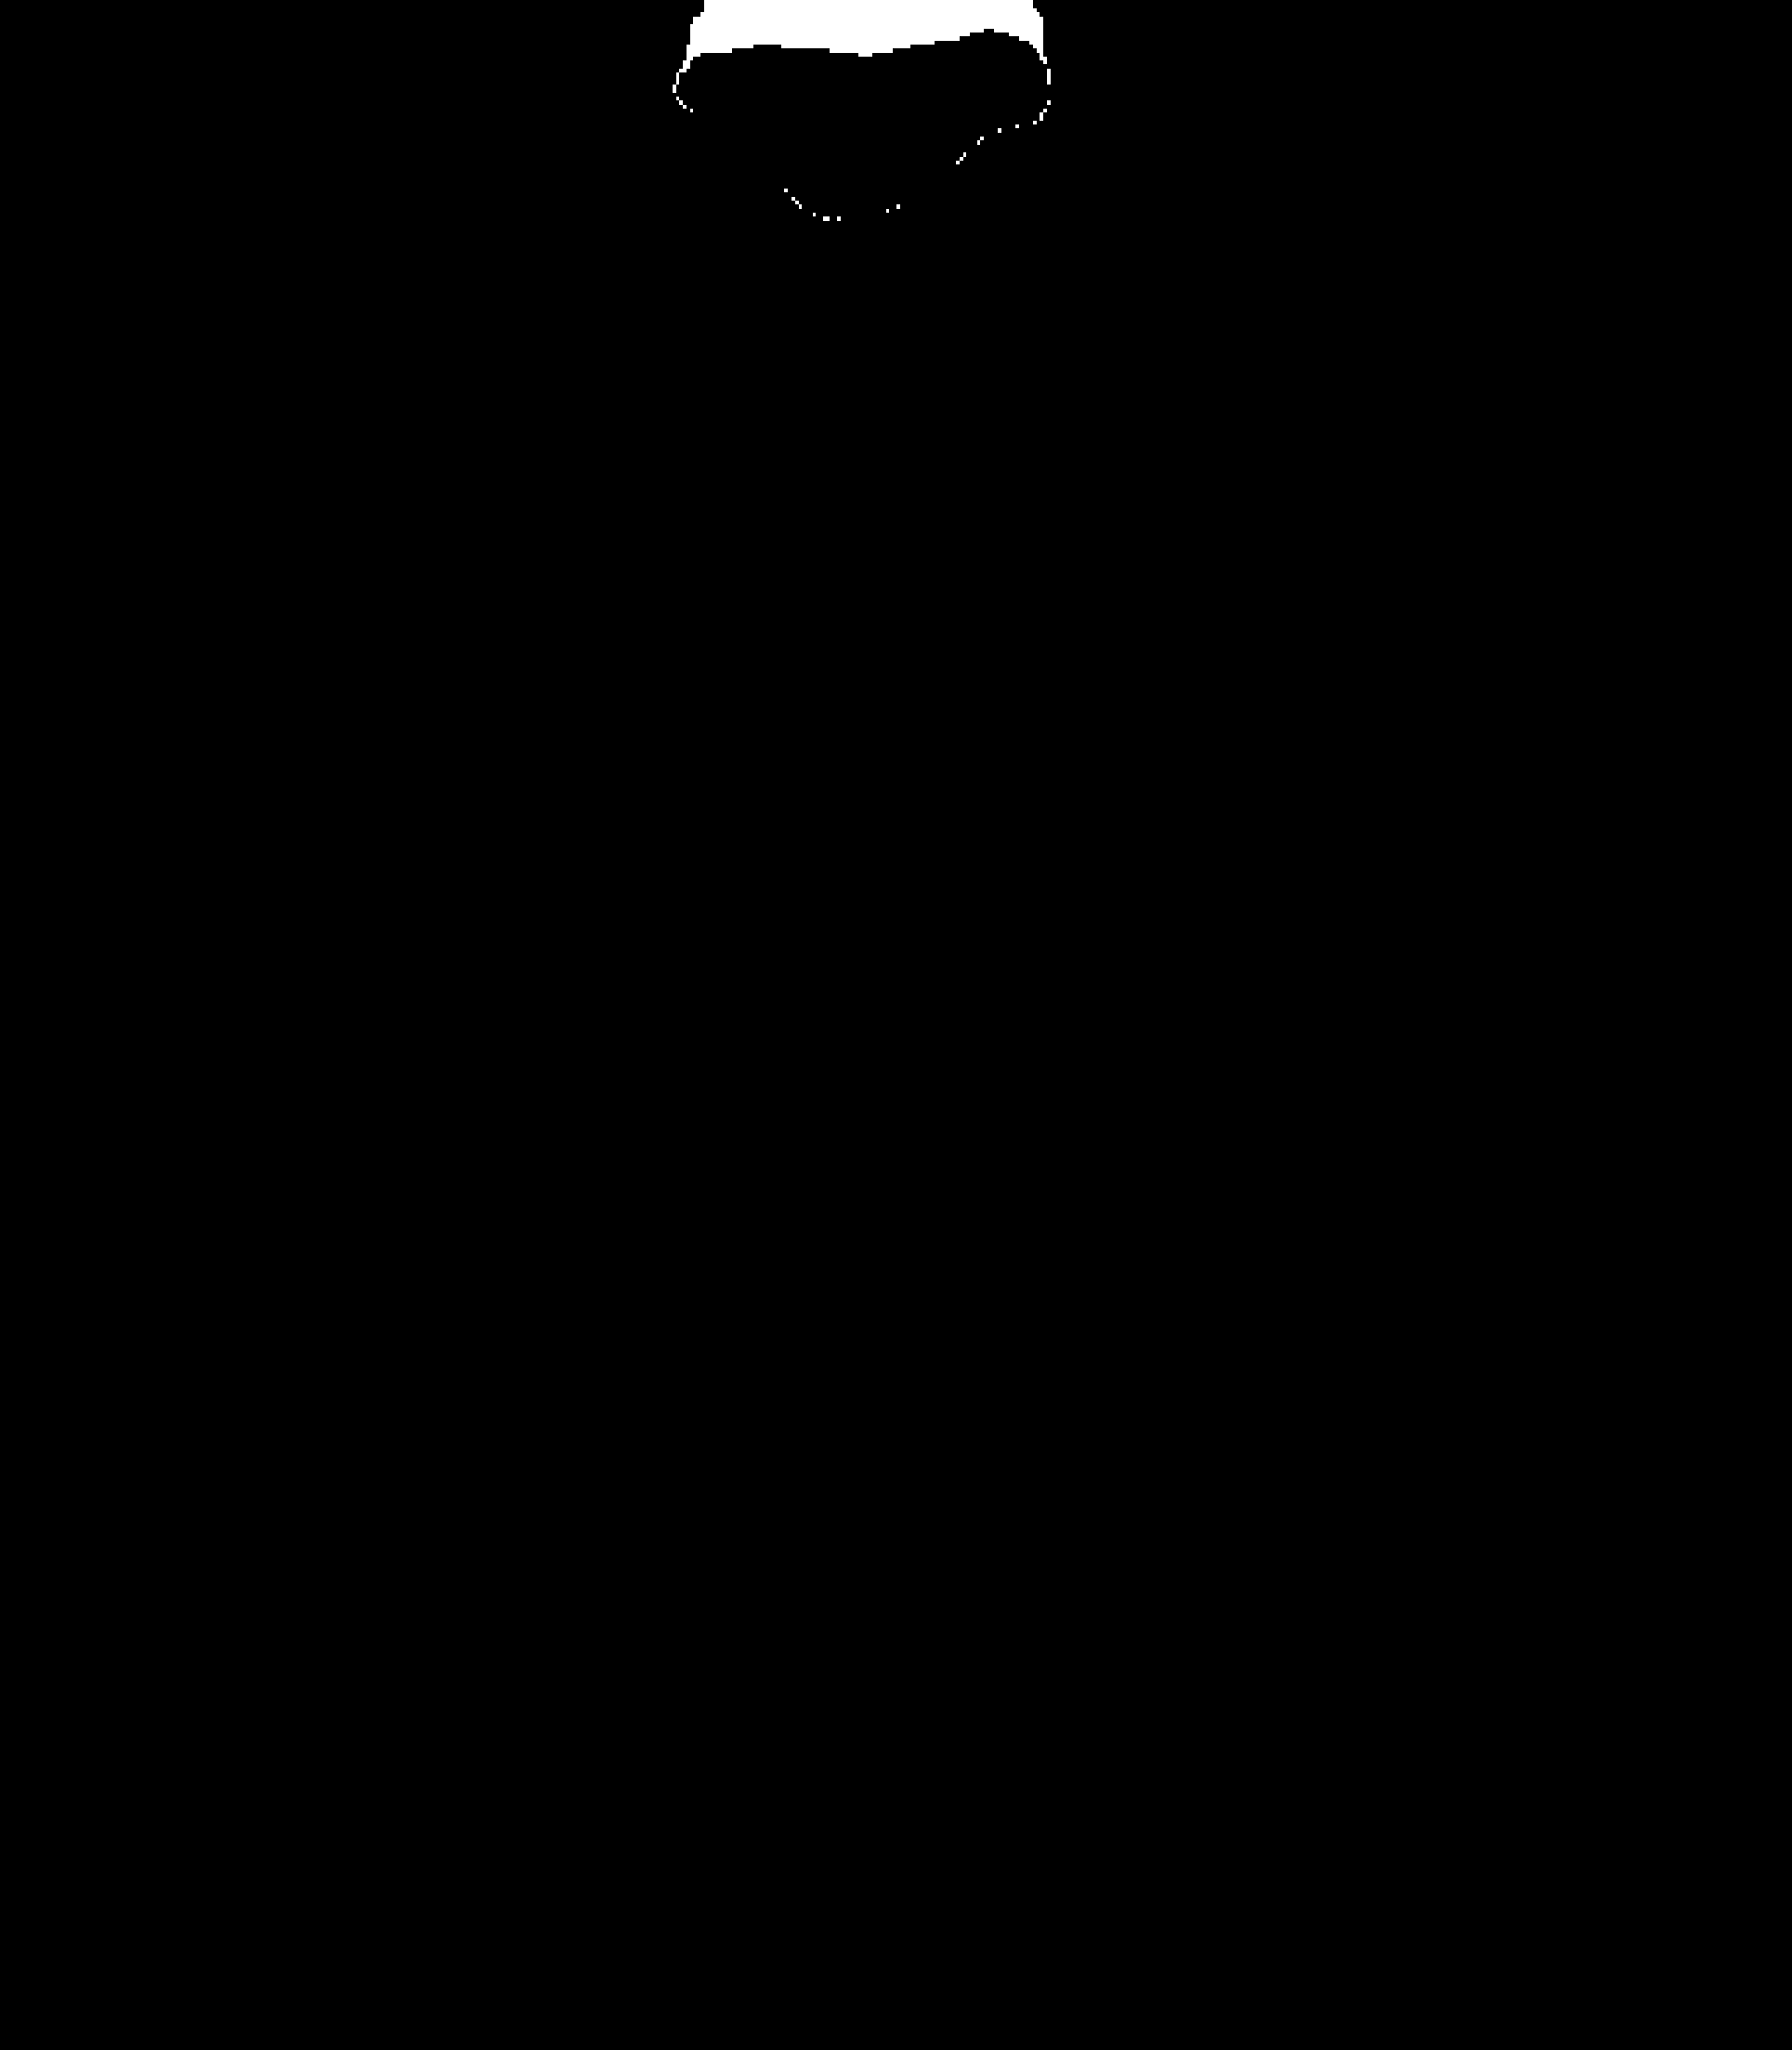

In [30]:
from PIL import Image
Image.fromarray(k[1]^k[10])


In [7]:
import numpy as np
k = np.load('cxas/data/reference_features.npz')
k['color_features'].shape

(2, 2048)